In [1]:
import numpy as np
from matplotlib import pyplot as plt

from pydrake.all import (
    DiagramBuilder,
    Integrator,
    JacobianWrtVariable,
    LeafSystem,
    MultibodyPlant,
    PiecewisePolynomial,
    PiecewisePose,
    RigidTransform,
    RotationMatrix,
    Simulator,
    StartMeshcat,
    TrajectorySource,
    StateInterpolatorWithDiscreteDerivative,
    Adder,
    LogVectorOutput,
)

from manipulation.station import LoadScenario, MakeHardwareStation
from manipulation.utils import RenderDiagram

In [2]:
meshcat = StartMeshcat()

INFO:drake:Meshcat listening for connections at http://localhost:7003


## Pseudo-Inverse Jacobian Controller

In [3]:
class PseudoInverseController(LeafSystem):
    def __init__(self, plant: MultibodyPlant):
        LeafSystem.__init__(self)
        self._plant = plant
        self._plant_context = plant.CreateDefaultContext()
        self._so101 = plant.GetModelInstanceByName("so101")
        self._G = plant.GetBodyByName("gripper_link", self._so101).body_frame()
        self._W = plant.world_frame()

        self.V_WG_port = self.DeclareVectorInputPort("V_WG", 6)
        self.x_port = self.DeclareVectorInputPort("so101.state", 12)
        self.DeclareVectorOutputPort("so101.velocity", 6, self.CalcOutput)

    def CalcOutput(self, context, output):
        V_WG_desired = self.V_WG_port.Eval(context)
        x = self.x_port.Eval(context)
        self._plant.SetPositionsAndVelocities(self._plant_context, self._so101, x)
        J_G = self._plant.CalcJacobianSpatialVelocity(
            self._plant_context,
            JacobianWrtVariable.kQDot,
            self._G,
            [0, 0, 0],
            self._W,
            self._W,
        )
        J_G = J_G[:, :5]  # Ignore gripper term

        v = np.linalg.pinv(J_G).dot(V_WG_desired)
        v = np.append(v, 0)
        # V_G_actual = J_G.dot(v)
        # print(f"V_G desired: {V_G_desired}, actual: {V_G_actual}")
        output.SetFromVector(v)

## Object-Relative Trajectory

In [4]:
def MakeGripperTrajectory(
    X_Ginitial: RigidTransform,
    X_Oinitial: RigidTransform,
    X_Ogoal: RigidTransform,
) -> PiecewisePose:
    X_G = {"initial": X_Ginitial}
    times = {"initial": 0.0}

    p_GgraspO = [0.02, 0, -0.12]
    R_GgraspO = RotationMatrix.MakeZRotation(np.pi / 2)
    X_GgraspO = RigidTransform(R_GgraspO, p_GgraspO)
    X_OGgrasp = X_GgraspO.inverse()
    X_G["pick"] = X_Oinitial @ X_OGgrasp
    X_G["pick_start"] = X_G["pick"]
    X_G["pick_end"] = X_G["pick"]

    X_GgraspGpregrasp = RigidTransform([0, 0, 0.05])
    X_G["prepick"] = X_G["pick"] @ X_GgraspGpregrasp
    X_G["postpick"] = X_G["prepick"]

    times["prepick"] = times["initial"] + 3.0
    times["pick_start"] = times["prepick"] + 2.0
    times["pick_end"] = times["pick_start"] + 1.0
    times["postpick"] = times["pick_end"] + 2.0

    frames = [
        "initial",
        "prepick",
        "pick_start",
        "pick_end",
        "postpick",
    ]
    sample_times = [times[frame] for frame in frames]
    poses = [X_G[frame] for frame in frames]
    traj_X_G = PiecewisePose.MakeLinear(sample_times, poses)
    return traj_X_G


def MakeFingerTrajectory() -> PiecewisePolynomial:
    finger_closed = np.array([0, 0, 0, 0, 0, 0.1])
    finger_opened = np.array([0, 0, 0, 0, 0, 0.4])
    q_finger = {"initial": np.zeros(6)}
    times = {"initial": 0.0}

    q_finger["prepick"] = finger_opened
    q_finger["pick_start"] = finger_opened
    q_finger["pick_end"] = finger_closed
    q_finger["postpick"] = finger_closed

    times["prepick"] = times["initial"] + 3.0
    times["pick_start"] = times["prepick"] + 2.0
    times["pick_end"] = times["pick_start"] + 1.0
    times["postpick"] = times["pick_end"] + 2.0

    frames = [
        "initial",
        "prepick",
        "pick_start",
        "pick_end",
        "postpick",
    ]
    sample_times = [times[frame] for frame in frames]
    positions = [q_finger[frame] for frame in frames]
    traj_q_finger = PiecewisePolynomial.FirstOrderHold(
        sample_times, 
        np.vstack(positions).T
    )
    return traj_q_finger

## Simulate

In [5]:
builder = DiagramBuilder()

scenario_path = "../scenarios/so101_block.yaml"
scenario = LoadScenario(filename=scenario_path)
station = builder.AddSystem(MakeHardwareStation(scenario, meshcat=meshcat))
plant: MultibodyPlant = station.GetSubsystemByName("plant")

so101_model = plant.GetModelInstanceByName("so101")
plant.SetDefaultPositions(so101_model, np.array([0, 0, 0, 1.5, 0, 0]))

X_Oinitial = RigidTransform(
    RotationMatrix.MakeZRotation(np.pi / 2),
    [-0.1, 0, 0.05]
)
X_Ogoal = RigidTransform(
    RotationMatrix.MakeZRotation(-np.pi / 2),
    [0.1, 0, 0]
)
brick_model = plant.GetModelInstanceByName("box")
brick_body = plant.GetRigidBodyByName("box_link", brick_model)
plant.SetDefaultFloatingBaseBodyPose(brick_body, X_Oinitial)

so101_gripper_body = plant.GetRigidBodyByName("gripper_link", so101_model)
temp_context = station.CreateDefaultContext()
temp_plant_context = plant.GetMyContextFromRoot(temp_context)
X_Ginitial = plant.EvalBodyPoseInWorld(temp_plant_context, so101_gripper_body)
X_Oinitial.set_translation([-0.1, 0, 0])
traj_X_G = MakeGripperTrajectory(X_Ginitial, X_Oinitial, X_Ogoal)
traj_V_G = traj_X_G.MakeDerivative()
V_G_source = builder.AddSystem(TrajectorySource(traj_V_G))

traj_q_finger = MakeFingerTrajectory()
traj_v_finger = traj_q_finger.MakeDerivative()
v_finger_source = builder.AddSystem(TrajectorySource(traj_v_finger))

controller = builder.AddSystem(PseudoInverseController(plant))
adder = builder.AddSystem(Adder(2, 6))
integrator = builder.AddSystem(Integrator(6))
interpolator = builder.AddSystem(StateInterpolatorWithDiscreteDerivative(6, 1e-4))
builder.Connect(
    controller.get_output_port(),
    adder.GetInputPort("u0")
)
builder.Connect(
    v_finger_source.get_output_port(),
    adder.GetInputPort("u1")
)
builder.Connect(
    adder.get_output_port(),
    integrator.get_input_port()
)
builder.Connect(
    integrator.get_output_port(),
    interpolator.get_input_port()
)
builder.Connect(
    interpolator.get_output_port(),
    station.GetInputPort("so101.desired_state")
)
builder.Connect(
    station.GetOutputPort("so101_state"),
    controller.GetInputPort("so101.state")
)
builder.Connect(
    V_G_source.get_output_port(),
    controller.GetInputPort("V_WG")
)

so101_force_logger = LogVectorOutput(
    station.GetOutputPort("so101_generalized_contact_forces"), 
    builder
)
so101_actuation_logger = LogVectorOutput(
    station.GetOutputPort("so101_net_actuation"), 
    builder
)

diagram = builder.Build()
# RenderDiagram(diagram)

simulator = Simulator(diagram)
simulator.set_target_realtime_rate(1.0)
context = simulator.get_mutable_context()
integrator.set_integral_value(
    integrator.GetMyContextFromRoot(context),
    plant.GetPositions(
        plant.GetMyContextFromRoot(context),
        plant.GetModelInstanceByName("so101"),
    ),
)

so101_force_log = so101_force_logger.FindLog(context)
so101_actuation_log = so101_actuation_logger.FindLog(context)

meshcat.StartRecording()
simulator.AdvanceTo(traj_V_G.end_time())
meshcat.StopRecording()
meshcat.PublishRecording()

## View Logs

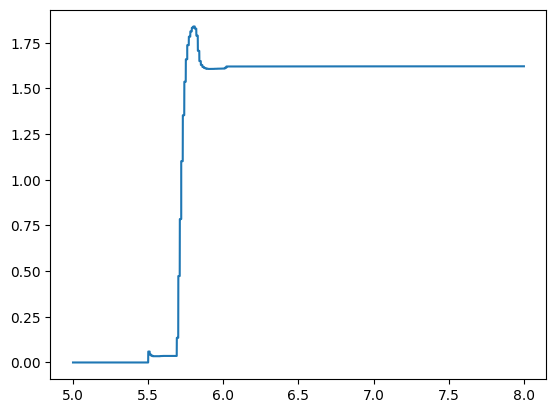

In [6]:
# force_nonzero_mask = np.any(so101_force_log.data(), axis=0)
force_times_mask = so101_force_log.sample_times() > 5
force_times = so101_force_log.sample_times()[force_times_mask]
force_outputs = np.linalg.norm(so101_force_log.data(), axis=0)[force_times_mask]

plt.plot(force_times, force_outputs)

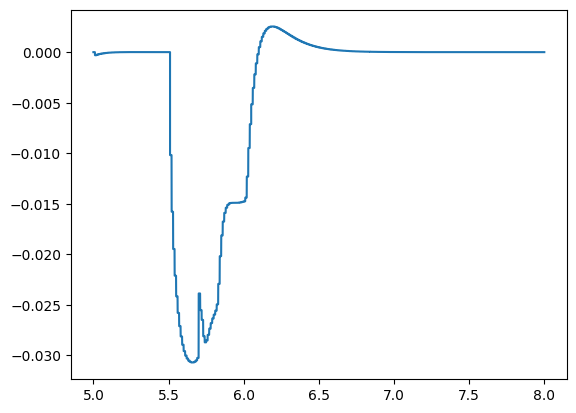

In [7]:
# actuation_nonzero_mask = np.abs(so101_actuation_log.data()[5, :]) > 0
# actuation_times = so101_actuation_log.sample_times()[actuation_nonzero_mask]
# actuation_outputs = so101_actuation_log.data()[5, :][actuation_nonzero_mask]

actuation_times_mask = so101_actuation_log.sample_times() > 5
actuation_times = so101_actuation_log.sample_times()[actuation_times_mask]
actuation_outputs = so101_actuation_log.data()[5, :][actuation_times_mask]

plt.plot(actuation_times, actuation_outputs)